In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv('../.env')

df = pd.read_csv('../data/raw/creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [2]:
# Cell 2 - data types and null check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
# Cell 3 - null rates
null_rates = df.isnull().sum() / len(df) * 100
print("Null rate per column (%):\n")
print(null_rates.sort_values(ascending=False).round(4))

Null rate per column (%):

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64


In [4]:
# Cell 5 - check for wrong values
print("WRONG VALUES CHECK\n" + "="*40)

print(f"Negative Amount:        {(df['Amount'] < 0).sum():,} rows")
print(f"Zero Amount:            {(df['Amount'] == 0).sum():,} rows")
print(f"Extreme Amount (>1000): {(df['Amount'] > 1000).sum():,} rows")
print(f"\n99th percentile Amount: ${df['Amount'].quantile(0.99):.2f}")
print(f"Max Amount:             ${df['Amount'].max():.2f}")
print(f"\nClass distribution (0=normal, 1=fraud):")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")

WRONG VALUES CHECK
Negative Amount:        0 rows
Zero Amount:            1,825 rows
Extreme Amount (>1000): 2,940 rows

99th percentile Amount: $1017.97
Max Amount:             $25691.16

Class distribution (0=normal, 1=fraud):
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


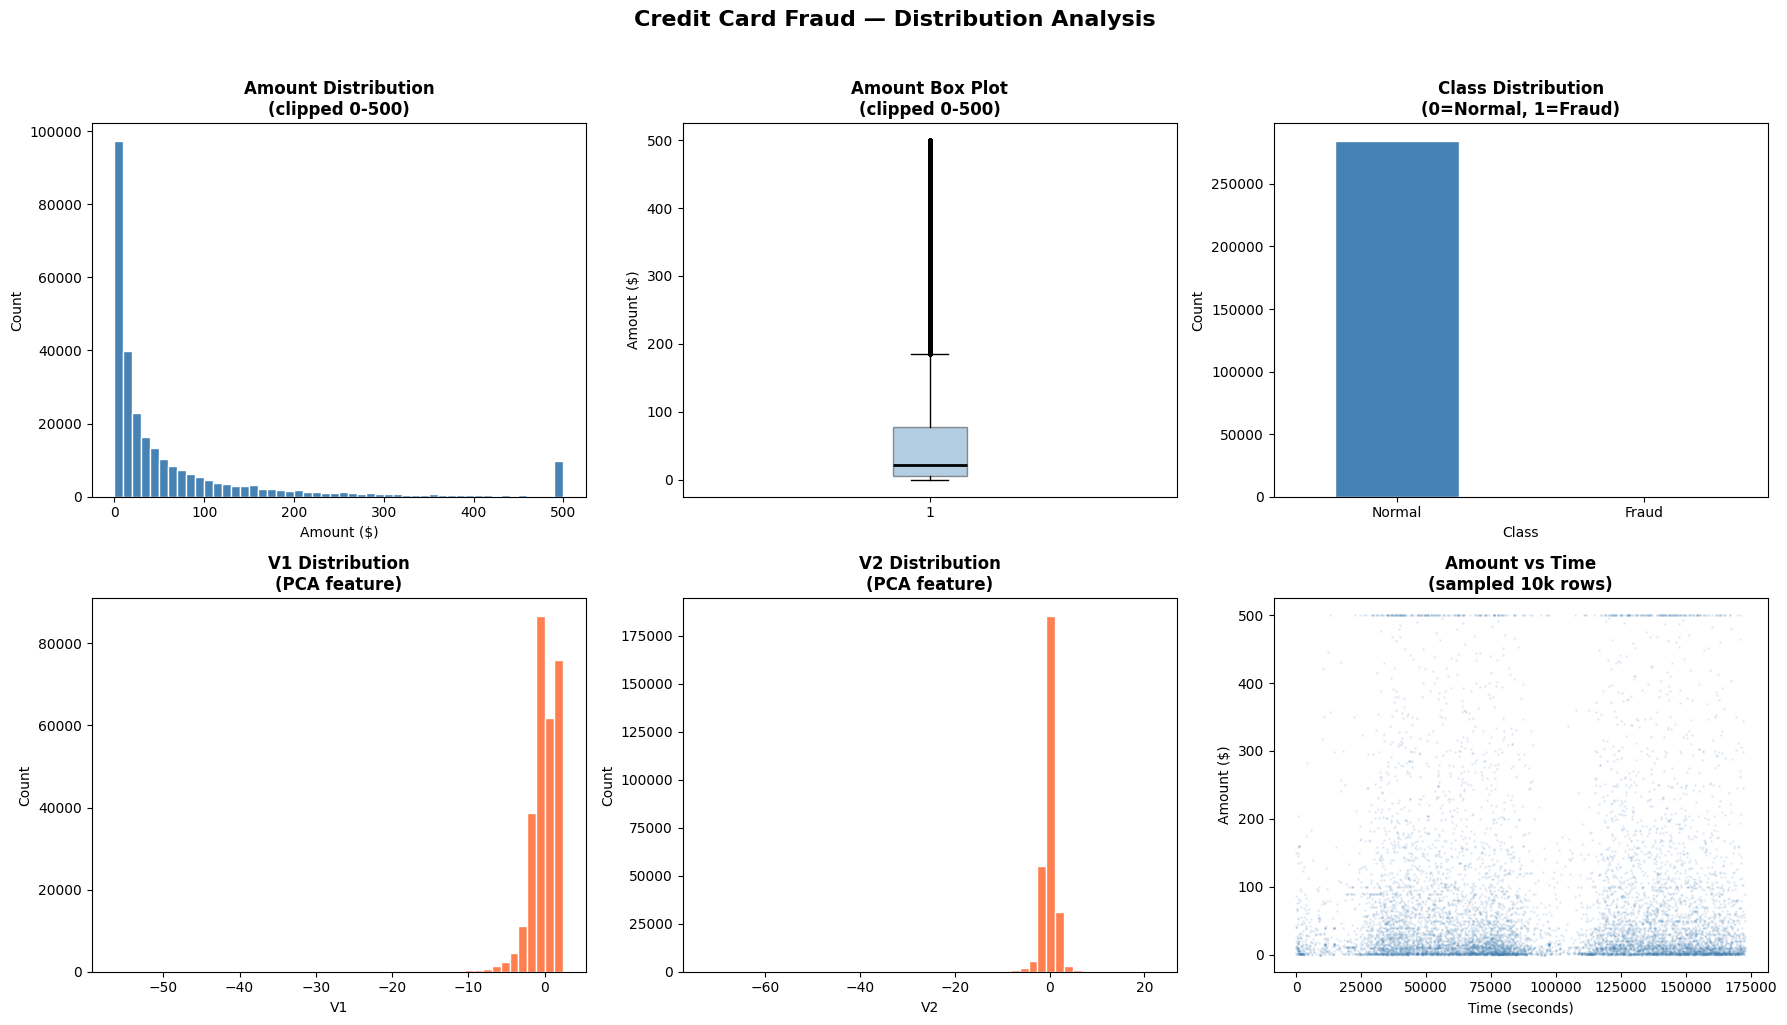

In [5]:
# Cell 6 - distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Amount distribution clipped
axes[0,0].hist(
    df['Amount'].clip(0, 500),
    bins=50,
    color='steelblue',
    edgecolor='white'
)
axes[0,0].set_title('Amount Distribution\n(clipped 0-500)', fontweight='bold')
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Count')

# Amount box plot
axes[0,1].boxplot(
    df['Amount'].clip(0, 500),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.4),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[0,1].set_title('Amount Box Plot\n(clipped 0-500)', fontweight='bold')
axes[0,1].set_ylabel('Amount ($)')

# Class distribution
df['Class'].value_counts().plot(
    kind='bar',
    ax=axes[0,2],
    color=['steelblue', 'coral'],
    edgecolor='white'
)
axes[0,2].set_title('Class Distribution\n(0=Normal, 1=Fraud)', fontweight='bold')
axes[0,2].set_xlabel('Class')
axes[0,2].set_ylabel('Count')
axes[0,2].set_xticklabels(['Normal', 'Fraud'], rotation=0)

# V1 distribution
axes[1,0].hist(
    df['V1'],
    bins=50,
    color='coral',
    edgecolor='white'
)
axes[1,0].set_title('V1 Distribution\n(PCA feature)', fontweight='bold')
axes[1,0].set_xlabel('V1')
axes[1,0].set_ylabel('Count')

# V2 distribution
axes[1,1].hist(
    df['V2'],
    bins=50,
    color='coral',
    edgecolor='white'
)
axes[1,1].set_title('V2 Distribution\n(PCA feature)', fontweight='bold')
axes[1,1].set_xlabel('V2')
axes[1,1].set_ylabel('Count')

# Amount vs Time scatter
sample = df.sample(n=10000, random_state=42)
axes[1,2].scatter(
    sample['Time'],
    sample['Amount'].clip(0, 500),
    alpha=0.1,
    s=1,
    color='steelblue'
)
axes[1,2].set_title('Amount vs Time\n(sampled 10k rows)', fontweight='bold')
axes[1,2].set_xlabel('Time (seconds)')
axes[1,2].set_ylabel('Amount ($)')

plt.suptitle('Credit Card Fraud — Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Cell 7 - percentile table
print("PERCENTILE TABLE — use for detector thresholds\n")
percentiles = [0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
result = df[['Amount', 'V1', 'V2', 'V3', 'Time']].quantile(percentiles)
result.index = [f'{int(p*100)}th' for p in percentiles]
print(result.round(2).to_string())

PERCENTILE TABLE — use for detector thresholds

       Amount    V1    V2    V3       Time
1th      0.12 -6.56 -4.96 -3.98    2422.00
25th     5.60 -0.92 -0.60 -0.89   54201.50
50th    22.00  0.02  0.07  0.18   84692.00
75th    77.16  1.32  0.80  1.03  139320.50
95th   365.00  2.08  1.81  2.06  164143.40
99th  1017.97  2.24  3.80  2.73  170560.94
99th  3000.00  2.34  7.85  3.39  172522.19


In [7]:
# Cell 8 - train test split preview
train_size = int(len(df) * 0.70)
df_train = df.iloc[:train_size]
df_monitor = df.iloc[train_size:]

print(f"Training rows:   {len(df_train):,}  (first 70%)")
print(f"Monitoring rows: {len(df_monitor):,}  (last 30%)")
print(f"\nFraud in training:   {df_train['Class'].sum():,} cases ({df_train['Class'].mean()*100:.3f}%)")
print(f"Fraud in monitoring: {df_monitor['Class'].sum():,} cases ({df_monitor['Class'].mean()*100:.3f}%)")
print(f"\nClass column is IGNORED by your system completely")
print(f"Only used by YOU manually to verify detection works")

Training rows:   199,364  (first 70%)
Monitoring rows: 85,443  (last 30%)

Fraud in training:   384 cases (0.193%)
Fraud in monitoring: 108 cases (0.126%)

Class column is IGNORED by your system completely
Only used by YOU manually to verify detection works


## EDA Findings — Credit Card Fraud

### Shape
- Rows: 284,807
- Columns: 31

### Null rates
- All columns: 0.000% null
- Cleanest dataset in the project — no missing values at all

### Column types
- Time: seconds elapsed since first transaction
- V1–V28: PCA transformed features (original features hidden for privacy)
- Amount: transaction amount in dollars
- Class: 0=normal, 1=fraud — THIS COLUMN IS IGNORED BY YOUR SYSTEM

### Fraud imbalance
- Normal transactions: 284,315 (99.827%)
- Fraud transactions: 492 (0.173%)
- Heavily imbalanced — typical for real fraud data

### Normal ranges — detector thresholds
- Amount: median=$22, 99th percentile=$X, max=$X (fill from Cell 7)
- V1–V28: roughly normally distributed around 0
- Time: 0 to 172,792 seconds (~48 hours of data)

### What detectors run on this dataset
- isolation_forest: YES — V1-V28 + Amount + Time
- null_rate_monitor: YES — though all currently 0% null
- distribution_drift: YES — main purpose of this dataset
- schema_drift: NO — no categorical columns
- timeseries: NO

### Train / Monitor split
- Training: first 70% = 199,364 rows
- Monitoring: last 30% = 85,443 rows

### How drift simulation works in Phase 2
- Take last 30% monitoring data
- Shift Amount column distribution — change from $0-500 range to $800-2000
- PSI score spikes above 0.2 → drift detected
- KS test p-value drops below 0.05 → distributions statistically different

### Special notes
- Class column exists but is completely ignored by the system
- Only used manually by you to verify flagged rows are real fraud
- V1-V28 are already scaled (PCA output) — no further scaling needed
- Isolation Forest works perfectly on PCA features
- This dataset has zero categorical columns — schema drift not applicable